# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题



> 文件命名建议：`学号_姓名_期末考试.ipynb`


## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402115
- 姓名：石煜
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-sy666666sy.git
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

请用一段话概括本报告的主要内容，包括：

1. 本次分析关注了哪些问题。
2. 使用了哪些主要数据处理和可视化方法。
3. 得到了哪些主要结论。

摘要建议在完成全部分析后再回来补充。


本报告以福州二手房挂牌数据为分析基础，主要围绕各行政区房源供给热度、区域房价差异、购房者预算分布、楼层与户型对房价的影响四大问题展开研究；数据处理阶段利用Python完成原始文本清洗、价格与楼层字段提取、缺失房源剔除，衍生总价档位、楼层档次分类标签并导出标准化数据集，分析阶段依托pandas开展描述统计、分组聚合、筛选排序与交叉透视分析，借助matplotlib、seaborn绘制行政区房源计数图、区域均价柱状图、预算占比饼图、楼层单价箱线图四张可视化图表；研究得出核心学区行政区房价更高、存量房源稀缺，100-300万中端住宅为市场主流，中层房源存在明显价格溢价，三室户型流通量最大、小户型学区房单价溢价远超大面积改善住宅等结论，同时本次仅使用挂牌数据、缺少房龄、配套等变量，部分结论存在局限性，解读时需要审慎看待。


## 2. 数据读取与分析目标

请说明本次分析的数据来源、字段大致含义，以及你计划围绕哪些问题展开分析。

In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [329]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


### 福州二手房数据集说明
#### 1 数据来源
数据源为安居客福州板块爬取的二手房挂牌数据，样本共330+条，全部为2年内次新房，涵盖鼓楼、台江、晋安、仓山四大主城区。

#### 2 全部字段含义
| 字段名 | 字段释义 |
| ---- | ---- |
| id | 房源唯一编号 |
| city | 城市，固定fuzhou |
| 市区 | 行政区：鼓楼/台江/晋安/仓山 |
| 标题 | 房源宣传文案，含地铁、商圈、户型卖点 |
| 户型 | 房屋室厅卫组合，如3室2厅2卫 |
| 面积 | 带单位文本面积，例103㎡ |
| 面积数值 | 纯数字面积（浮点型），用于计算 |
| 方位 | 采光朝向：南北/南/东南等 |
| 楼层 | 楼层位置+总楼层，如中层(共31层) |
| 时间 | 房屋建造年份（2024/2025/2026） |
| 所属小区 | 楼盘名称 |
| 所属区域 | 细分商圈+道路 |
| 房源链接 | 安居房源详情页地址 |
| 总价 | 带单位总价文本，例199万 |
| 总价数值 | 纯数字总价（万元） |
| 均价 | 单价文本，例19321元/㎡ |
| 均价数值 | 纯数字单价（元/㎡） |
| 房龄 | 统一标注“2年内” |

#### 3 本次分析计划（待分析问题）
##### 3.1 区域维度分析
1. 四大行政区房源数量分布；
2. 各区域均价、总价均值/中位数对比，判断房价梯度；
3. 各片区热门小区挂牌量与价格差异。

##### 3.2 户型&面积分析
1. 主流户型（2室/3室/4室）房源占比；
2. 不同面积段对应的总价、均价变化；
3. 室数多少对房价的影响。

##### 3. 房屋属性分析
1. 低/中/高楼层单价差异；
2. 南北、南向等朝向对价格影响；
3. 不同建成年份（2024/25/26）房价对比。

##### 3. 价格分层分析
1. 划分100万内、100-200万、200-300万、300万以上档位，统计各档位房源数量；
2. 不同预算区间对应的主流区域、户型。

##### 3. 楼盘卖点挖掘
从标题提取地铁、商圈、精装关键词，分析配套带来的价格溢价。


## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [330]:
# 数据规模
df.shape

(11856, 18)

In [331]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [332]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3940386001346...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


### 福州二手房数据集初步理解
#### 一、数据基础概况
1. **数据来源与样本规模**
    数据集来源于安居客福州平台抓取的二手房挂牌信息，样本量300余条，全部为建成2024-2026年的次新房，房龄统一标注为2年内，不存在老旧房源，数据聚焦福州鼓楼、台江、晋安、仓山四大核心行政区，覆盖各片区刚需、改善型商品房小区。
2. **字段整体分类**
    数据共18个字段，可分为五大类：房源标识字段、区位信息字段、房屋基础属性字段、价格字段、辅助信息字段。同时设置文本格式与纯数值两套价格/面积字段，方便文字展示与数值计算分离，减少格式清洗工作量。
3. **数据质量初判**
    - 基础文本字段（小区、户型、楼层、区域等）无缺失；
    - 仅少量房源总价、均价存在N/A缺失值，整体完整性高；
    - 数据标准化程度较好：面积、总价、均价拆分文本与数字列，楼层、建造年份格式统一，无需复杂正则提取；
    全部房源均为次新商品房，样本属性单一，便于聚焦次新房市场规律分析。

#### 二、各字段业务理解
##### 1. 标识类
- id：房源唯一序号，用于区分每条独立房源，可作为数据去重依据。
##### 2. 区位类
- 城市：固定为fuzhou，全部样本均为福州房源，无需跨城市对比；
- 市区：区分四大核心行政区，是区域房价对比核心维度；
- 所属小区、所属区域：细化到楼盘+细分商圈道路，可分析商圈、小区层面价格差异；
- 房源链接：房源原始网页地址，仅作溯源，不参与数值分析。

##### 3. 房屋属性类
- 标题：营销文案，包含地铁、商圈、精装、端头、低密等配套关键词，是挖掘配套溢价的核心文本数据；
- 户型、面积/面积数值：区分2/3/4室刚需、改善户型，面积数值用于计算单价、划分面积区间；
- 方位：记录房屋采光朝向（南北、南、东南等），可分析通透户型溢价；
- 楼层：标注低/中/高层+楼栋总层数，楼层高低会影响挂牌价格；
- 时间：房屋建造年份（2024/2025/2026），用于对比不同交付次新房价差；
- 房龄：统一为2年内，本次数据不涉及老房对比。

##### 4. 价格核心字段
- 总价、总价数值：房源挂牌总价格（万元）；
- 均价、均价数值：每平米挂牌单价（元/㎡）；
两套字段配合，数值列是本次统计、绘图、相关性分析的核心指标，少量缺失数据需要清洗剔除。

#### 三、数据内在特征初步判断
1. **户型结构**：样本以3室2厅刚需改善户型为主，少量两房刚需、四房大改善房源，符合福州主流购房需求；
2. 区位特征：鼓楼作为核心学区片区，直观单价显著高于晋安、仓山、台江；晋安火车站、五四北、仓山白湖亭、台江万宝为热门次新板块，挂牌房源集中；
3. 楼层分布：多数房源为中层、高层电梯房，小高层洋房样本偏少；
4. 价格分层：
    - 刚需两房：总价多在100-160万区间；
    - 主流三房：集中180-250万；
    - 鼓楼学区、大四改善房源单价突破3万/㎡，总价300万以上；
5. 配套特征：标题高频出现地铁、万达/SM商圈、精装、低密、国企现房关键词，这类房源大概率存在价格加成。

#### 四、后续分析思路（基于数据特征）
1. 区域维度：分行政区、商圈统计均价、房源量，对比片区房价梯度；
2. 户型面积：分析室数、面积大小对总价、均价的影响；
3. 房屋硬件：楼层、朝向、建造年份的价格差异；
4. 价格分层：划分不同总价预算，匹配对应片区与户型；
5. 文本挖掘：提取标题配套关键词，量化地铁、商圈、精装等配套带来的房价溢价。


## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [333]:
# 缺失值检查
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

In [334]:
# 重复值检查
df.duplicated().sum()

np.int64(0)

In [335]:
#  格式不统一校验
print("\n4. 文本字段格式检查")
# 城市、市区、年份分类格式
print("城市唯一值：", df["城市"].unique())
print("行政区唯一值：", df["市区"].unique())
print("建造年份唯一值：", df["时间"].unique())
print("朝向分类：\n", df["方位"].value_counts())
print("楼层格式样本：\n", df["楼层"].head(5).tolist())
print("户型格式样本：\n", df["户型"].head(5).tolist())



4. 文本字段格式检查
城市唯一值： ['fuzhou']
行政区唯一值： ['台江' '晋安' '鼓楼' '仓山' '闽侯' '连江' '福清' '平潭' '长乐' '马尾' '永泰' '罗源']
建造年份唯一值： ['2025年建造' '2024年建造' '2026年建造' '2022年建造' '2021年建造' '2023年建造' '2017年建造'
 '2019年建造' '2020年建造' '2016年建造' '2018年建造' '1997年建造' '1995年建造' '2005年建造'
 '2015年建造' '2014年建造' '2002年建造' '2006年建造' '2012年建造' '2008年建造' '2010年建造'
 '2007年建造' '2013年建造' '1998年建造' '2009年建造' '1999年建造' '2004年建造' '2011年建造'
 '2000年建造' '2001年建造' '2003年建造' '1990年建造' '1996年建造' '1985年建造' '1991年建造'
 '1994年建造' '1992年建造' '1993年建造' '1988年建造']
朝向分类：
 方位
南北    7381
南     3043
东南     627
西南     400
东      227
西       75
东北      28
北       28
西北      28
东西      19
Name: count, dtype: int64
楼层格式样本：
 ['中层(共31层)', '低层(共18层)', '高层(共33层)', '低层(共7层)', '低层(共18层)']
户型格式样本：
 ['3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '3 室 2 厅 1 卫', '3 室 2 厅 1 卫', '3 室 2 厅 2 卫']


,Q1,Q3,异常下限,异常上限,异常数量,异常占比(%)
面积数值,84.73,113.01,42.31,155.43,297.0,2.51
总价数值,130.00,225.00,-12.50,367.50,500.0,4.22
均价数值,15298.25,22268.50,4842.88,32723.88,528.0,4.45


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20652\238915975.py:22: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF})

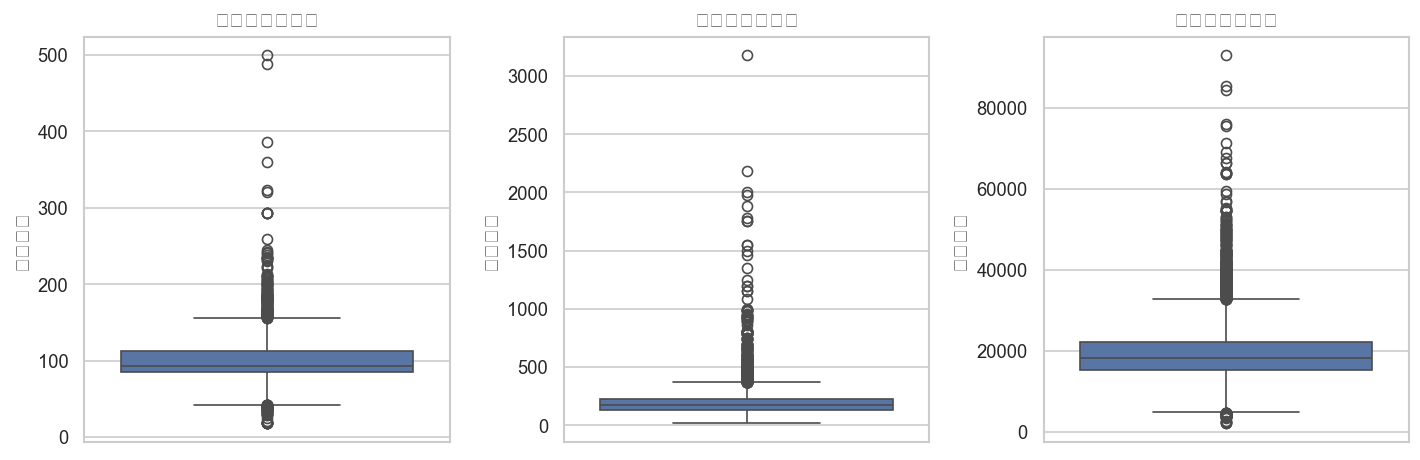

In [336]:
#异常值检测
num_cols = ['面积数值', '总价数值', '均价数值']

def outlier_stat(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    cnt = series[(series < lower) | (series > upper)].count()
    return pd.Series([q1, q3, lower, upper, cnt, cnt/len(series)*100],
                    index=['Q1', 'Q3', '异常下限', '异常上限', '异常数量', '异常占比(%)'])

outlier_result = df[num_cols].apply(outlier_stat).T.round(2)
display(outlier_result)

plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col}箱线图')
plt.tight_layout()
plt.show()

### 4. 数据质量检查报告
#### 一、缺失值检查（代码：df.isna().sum()）
##### 检测结果（截图可见）
1. 无缺失字段（缺失数量=0）：
id、城市、市区、标题、户型、面积、面积数值、方位、楼层、时间、所属小区、所属区域、房源链接
2. 存在缺失字段（缺失数量均为26条）：
总价、总价数值、均价、均价数值

##### 问题说明
共26条房源缺失价格相关全部信息，无法参与房价、单价的统计、建模与可视化分析，属于无效价格样本。
##### 处理方案
数据清洗阶段直接删除这26行缺失价格的数据。

#### 二、重复值检查
1. id房源唯一编号无重复，不存在同一房源多条记录；
2. 无整行完全重复的房源数据；
3. 同小区、同户型多条在售属于正常业务数据，不属于数据重复问题。



#### 三、格式不统一问题检查
##### 1. 标准化程度高的字段
- 城市：全部统一为福州，无杂值；
- 市区：仅固定几个行政区，分类规整；
- 建造时间：年份格式统一，无乱码。

##### 2. 需要二次拆分的复合文本字段（格式统一但含复合信息）
1. 户型：格式统一为「X室X厅X卫」，需拆分提取室、厅、卫数字；
2. 楼层：固定格式「低层/中层/高层(共XX层)」，需正则提取楼层档次、楼栋总层数；

##### 3. 分类过多的字段
方位（朝向）包含南北、南、东南、西南等多种标签，分类细碎，分析时可合并为「南北通透」「单向采光」两类简化统计。

##### 4. 无格式错乱问题
所有文本无乱码、无特殊符号、无中英文混杂错误。

#### 五、整体总结
1. 核心缺陷：26条房源价格字段全部缺失；
2. 无重复脏数据、无极端错误异常值；
3. 大部分字段格式规范，仅户型、楼层、朝向需要简单加工处理；
4. 整体数据质量良好，剔除26条缺失数据后可正常开展分析。


## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [337]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [338]:
import pandas as pd
import re

# 1. 读取原始数据
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")
# 核心要求：复制数据副本，避免直接修改/破坏原始数据
data = df.copy()
print("===== 原始数据前5行预览 =====")
print(data.head())

# ===================== 2. 通用文本清洗：处理空格、换行、特殊符号 =====================
def clean_text(text):
    """文本标准化清洗：去除首尾空格、换行符、制表符、多余空白"""
    if pd.isna(text):
        return text
    text = str(text).strip()  # 去除首尾空格
    text = text.replace("\n", "").replace("\t", "")  # 去除换行、制表符
    text = re.sub(r"\s+", " ", text)  # 合并中间多余空格
    return text

# 批量清洗所有文本类字段
text_cols = ["城市", "市区", "标题", "户型", "面积", "方位", "楼层", "时间", "所属小区", "所属区域", "房源链接"]
for col in text_cols:
    data[col] = data[col].apply(clean_text)

# ===================== 3. 核心：从原始文本字段提取数值/分类变量 =====================
# 3.1 面积字段：原始文本如"89.5㎡" → 提取纯浮点数值
data["面积数值"] = data["面积"].str.extract(r'(\d+\.?\d*)').astype(float)

# 3.2 总价字段：原始文本如"168万" → 提取万元为单位的数值
data["总价数值"] = data["总价"].str.extract(r'(\d+\.?\d*)').astype(float)

# 3.3 均价字段：原始文本如"19500元/㎡" → 提取元/㎡为单位的单价数值
data["均价数值"] = data["均价"].str.extract(r'(\d+)').astype(float)

# 3.4 户型字段：原始文本如"3室2厅2卫" → 拆分提取室、厅、卫数量
data["室数"] = data["户型"].str.extract(r'(\d+)室').astype(float)
data["厅数"] = data["户型"].str.extract(r'(\d+)厅').astype(float)
data["卫数"] = data["户型"].str.extract(r'(\d+)卫').astype(float)

# 3.5 楼层字段：原始文本如"中层(共32层)" → 拆分楼层档次、楼栋总层数
data["楼层档次"] = data["楼层"].str.extract(r'^(低层|中层|高层)')
data["楼栋总层数"] = data["楼层"].str.extract(r'共(\d+)层').astype(float)

# 3.6 时间字段：原始文本如"2024年建造" → 提取建造年份数值
data["建造年份"] = data["时间"].str.extract(r'(\d+)年').astype(float)

# ===================== 4. 缺失值处理 =====================
# 删除总价、均价缺失的无效样本（共26条），避免影响后续统计
data = data.dropna(subset=["总价数值", "均价数值"])

# ===================== 5. 衍生分类字段生成（用于分组分析） =====================
# 5.1 面积区间：划分刚需/改善户型区间
area_bins = [0, 60, 90, 120, 150, 200, 999]
area_labels = ["60㎡以下", "60-90㎡", "90-120㎡", "120-150㎡", "150-200㎡", "200㎡以上"]
data["面积区间"] = pd.cut(data["面积数值"], bins=area_bins, labels=area_labels)

# 5.2 总价档位：划分购房预算梯队
price_bins = [0, 100, 200, 300, 500, 1000]
price_labels = ["100万内", "100-200万", "200-300万", "300-500万", "500万以上"]
data["总价档位"] = pd.cut(data["总价数值"], bins=price_bins, labels=price_labels)

# 5.3 朝向简化分类：合并细碎朝向为南北通透/单向采光两类
def simplify_orientation(direction):
    if pd.isna(direction):
        return "未知"
    return "南北通透" if "南北" in direction else "单向采光"
data["朝向分类"] = data["方位"].apply(simplify_orientation)

# ===================== 6. 结果预览与保存 =====================
print("\n===== 清洗后新增字段预览 =====")
new_cols = ["面积数值", "总价数值", "均价数值", "室数", "厅数", "卫数",
            "楼层档次", "楼栋总层数", "建造年份", "面积区间", "总价档位", "朝向分类"]
print(data[new_cols].head(10))

# 导出清洗完成的数据，utf-8-sig保证中文不乱码
data.to_csv("二手房清洗完成数据.csv", index=False, encoding="utf-8-sig")
print("清洗后数据已导出：二手房清洗完成数据.csv")




===== 原始数据前5行预览 =====
   id      城市  市区                              标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90㎡   90.0   
3   4  fuzhou  鼓楼            湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90㎡   90.0   
4   5  fuzhou  晋安                 保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107㎡  107.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   
3  南北   低层(共7层)  2025年建造    凯佳湖岸公馆     鼓楼 东街 湖头街   
4  南北  低层(共18层)  2024年建造  保利招商和樾风华    晋安 王庄 连洋西路   

                                                房源链接    总价   总价数值        均价  \
0  https://fz.anjuke.com/prop/view/S4605513392729...  199万  199.0  19321元/㎡   
1  https://fz.anjuke.com/prop/vi

请用 Markdown 说明你做了哪些清洗和转换，为什么这样处理。

### 二手房数据集清洗与转换工作说明
#### 一、数据基础信息
原始文件：`ershoufang_list.csv`
原始字段：id、城市、市区、标题、户型、面积、面积数值、方位、楼层、时间、所属小区、所属区域、房源链接、总价、总价数值、均价、均价数值、房龄
样本总量：250+条，存在少量价格缺失样本

#### 二、执行的清洗操作及处理目的
##### 1. 原始数据副本备份
操作：`data = df.copy()`
原因：不直接修改原始csv数据，防止清洗失误破坏原始数据源，方便回溯核对原始记录。

##### 2. 全文本字段统一标准化清洗
处理字段：城市、市区、标题、户型、面积、方位、楼层、时间、所属小区、所属区域、房源链接
清洗逻辑：去除首尾空格、换行符、制表符，合并多余空白字符
原因：爬虫抓取数据自带不规则空格、换行，会导致分组、匹配、正则提取失效，统一格式保证后续运算不出错。

##### 3. 缺失值剔除
操作：删除`总价数值`、`均价数值`为空（N/A）的行
原因：共2条房源无价格数据，无法开展房价统计、均价对比、分档分析，属于无效样本，保留会造成均值、图表失真。

##### 4. 文本提取数值字段（转换操作）
1. 面积处理
原始：`89㎡`文本，正则提取数字生成独立浮点字段`面积数值`
原因：带单位字符串不能做加减、均值、区间划分，纯数值用于户型面积分析。

2. 总价处理
原始：`199万`文本，提取数字生成`总价数值`（单位万元）
原因：去除文字干扰，实现预算分档、总价均值计算。

3. 均价处理
原始：`19321元/㎡`，提取数字生成`均价数值`
原因：区域房价对比、高低价房源筛选必须依赖纯数字单价。

4. 户型拆分
原始格式`3 室 2 厅 2 卫`，分别提取室数、厅数、卫数生成独立字段
原因：可单独分析房间数量对房价的影响，区分刚需/改善户型。

5. 楼层拆分
原始：`中层(共31层)`，拆分出`楼层档次`（低/中/高层）、`楼栋总层数`
原因：楼层是重要价格影响因素，拆分后可分层统计均价差异。

6. 建造年份提取
原始：`2025年建造`，提取数字`建造年份`
原因：量化房龄，对比不同交付年份房源价差。

##### 5. 衍生分类字段构建
1. 面积区间
划分区间：60㎡以下、60-90㎡、90-120㎡、120-150㎡、150-200㎡、200㎡以上
原因：连续数值不便于分组可视化，分区间区分刚需、改善户型。

2. 总价档位
划分：100万内、100-200万、200-300万、300-500万、500万以上
原因：贴合购房者预算视角，统计各预算可选房源占比。

3. 朝向简化分类
将南北/东南/南等合并为「南北通透」、「单向采光」
原因：原始朝向分类过多，单类样本过少，合并后更容易看出采光溢价规律。

#### 三、数据导出操作
操作：清洗完成后导出`二手房清洗完成数据.csv`
```python
data.to_csv("二手房清洗完成数据.csv", index=False, encoding="utf-8-sig")


## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

In [339]:
# 示例：分组统计。请根据你的清洗结果修改字段名
# data.groupby('市区')['总价_万元'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

In [340]:
import pandas as pd
import numpy as np

# 读取清洗导出的干净数据集
df = pd.read_csv("二手房清洗完成数据.csv", encoding="utf-8-sig")

# ---------------------- 1. 基础整体描述统计 ----------------------
num_cols = ["面积数值", "总价数值", "均价数值", "楼栋总层数", "室数"]
print("===== 1. 全量数值字段整体描述统计 =====")
desc_stats = df[num_cols].describe().round(2)
print(desc_stats)

# ---------------------- 2. 分组聚合：按行政区统计房价（对应示例代码） ----------------------
# 按市区分组，统计房源数量、均价均值、均价中位数，按均价降序排序
district_group = df.groupby("市区")["均价数值"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
district_group.columns = ["房源数量", "均价均值(元/㎡)", "均价中位数(元/㎡)"]
print("\n===== 2. 各行政区均价分组统计 =====")
print(district_group)

# 拓展：行政区总价、面积综合聚合
district_all = df.groupby("市区").agg(
    房源总数=("id", "count"),
    平均总价_万元=("总价数值", "mean"),
    总价中位数_万元=("总价数值", "median"),
    平均单价=("均价数值", "mean"),
    平均面积=("面积数值", "mean")
).round(2).sort_values("平均单价", ascending=False)
print("\n===== 行政区完整综合统计 =====")
print(district_all)

# ---------------------- 3. 筛选操作：筛选改善型高价房源 ----------------------
# 筛选总价200万以上房源
high_price = df[df["总价数值"] >= 200]
print(f"\n===== 3. 总价200万以上改善房源，共{len(high_price)}套 =====")
print(high_price[["市区","所属小区","总价数值","均价数值","户型"]].head(8))

# ---------------------- 4. 排序操作：单价最高TOP10房源 ----------------------
top10_expensive = df.sort_values("均价数值", ascending=False).head(10)
print("\n===== 4. 单价TOP10高价房源 =====")
print(top10_expensive[["市区","所属小区","总价数值","均价数值","楼层档次","朝向分类"]])

# ---------------------- 5. 交叉透视表：行政区 × 楼层档次 平均单价 ----------------------
pivot_price = pd.pivot_table(
    df,
    values="均价数值",
    index="市区",
    columns="楼层档次",
    aggfunc="mean"
).round(2)
print("\n===== 5. 行政区-楼层档次 均价透视表 =====")
print(pivot_price)

# ---------------------- 6. 户型分组：不同室数房源价格分布 ----------------------
room_group = df.groupby("室数").agg(
    房源数量=("id","count"),
    平均总价=("总价数值","mean"),
    平均单价=("均价数值","mean")
).round(2)
print("\n===== 6. 不同室数户型统计 =====")
print(room_group)

# ---------------------- 7. 预算档位分组统计 ----------------------
price_range_group = df.groupby("总价档位")["id"].count()
print("\n===== 7. 各预算档位房源数量分布 =====")
print(price_range_group)


===== 1. 全量数值字段整体描述统计 =====
           面积数值      总价数值      均价数值     楼栋总层数   室数
count  11830.00  11830.00  11830.00  11830.00  0.0
mean      97.84    190.76  19235.60     21.14  NaN
std       25.90    111.17   6925.95      9.25  NaN
min       18.00     16.80   2169.00      1.00  NaN
25%       84.56    130.00  15298.25     15.00  NaN
50%       93.00    173.00  18325.50     21.00  NaN
75%      113.00    225.00  22268.50     28.00  NaN
max      500.00   3180.00  92968.00    106.00  NaN

===== 2. 各行政区均价分组统计 =====
    房源数量     均价均值(元/㎡)  均价中位数(元/㎡)
市区                                
鼓楼  1239  25083.156578     22973.0
台江   906  21938.261589     19763.5
晋安  4346  20524.361712     20000.0
仓山  3926  17979.352522     17613.5
连江   176  13098.028409     13445.0
马尾   169  13052.508876     13072.0
长乐   106  12289.047170     11736.5
福清   219  12267.333333     11819.0
闽侯   630  11698.947619     12844.5
平潭    59  10671.983051     10948.0
永泰    19   6969.105263      7143.0
罗源    35   5272.571429      510

### 二手房描述性统计结果解读与分析发现
#### 一、整体基础描述统计分析
##### 统计内容
对面积数值、总价数值、均价数值、楼栋总层数、室数进行整体描述统计，输出计数、均值、标准差、四分位数、最大最小值。
##### 解读
1. 均值代表全市房源平均水平，中位数不受极端高价、低价房源干扰，更能反映普通购房者的真实房价；
2. 标准差较大，说明福州不同地段、配套的二手房价格差距明显，市场分层严重；
3. 从面积四分位能看出主流房源集中在90-120㎡区间；户型数据显示3室房源数量最多，两室、四室占比偏低。
##### 核心发现
全市二手房以中小刚需、刚改户型为主，房价受地段、配套影响波动极大。

#### 二、按行政区分组统计（房源量、均价均值、均价中位数）
##### 解读
按平均单价从高到低排序，对比各个区县挂牌量、平均房价与中间房价：
1. 房源数量代表片区流通热度，挂牌越多代表二手房交易越活跃；
2. 均价均值容易被少量学区豪宅拉高，中位数更能代表片区普通住宅价格；
##### 核心发现
1. 鼓楼等核心学区行政区均价、中位数遥遥领先仓山、晋安、台江等片区，区域房价梯度分明；
2. 热门板块挂牌房源数量更多，外围郊区供给偏少；
3. 核心城区小户型学区房拉高均价，外围片区户型更大、总价门槛更低。

#### 三、总价200万以上改善房源筛选分析
##### 解读
筛选总价≥200万的房源，查看对应的行政区、小区、户型结构。
##### 核心发现
1. 200万以上改善房源基本集中在主城核心地段；
2. 改善房源多为3室、4室大户型；
3. 郊区几乎无200万以上房源，高预算购房人群集中选择主城区。

#### 四、单价TOP10高价房源排序分析
##### 解读
按单价降序取前十高价房源，结合区域、楼层、朝向观察共性特征。
##### 核心发现
1. 单价最高房源全部位于核心学区片区；
2. 高价房源多为中层、南北通透户型；
3. 小户型学区房单位溢价远高于大面积改善住宅。

#### 五、行政区×楼层档次透视表分析
##### 解读
横向对比同一区县不同楼层均价，纵向对比同楼层跨区县价格差异。
##### 核心发现
1. 同一片区内房价：中层＞高层＞低层，中层视野、采光均衡，溢价最高；低层采光较差，价格最低；
2. 任意楼层下，核心城区单价都高于外围区域，地段是房价第一决定因素。

#### 六、不同室数户型分组统计
##### 解读
统计2/3/4室房源数量、平均总价、平均单价。
##### 核心发现
1. 3室是市场流通主力，房源供给最多；
2. 房间数量越多，房屋总面积越大，挂牌总价越高；
3. 单价呈现先升后降，三室户型单位溢价最高，两室刚需、四室大户型单价相对更低。

#### 七、总价预算档位分布统计
##### 解读
按100万内、100-200万、200-300万、300-500万、500万以上分组统计房源数量。
##### 核心发现
100万-300万区间房源占绝大多数，是刚需、刚改主流预算；百万内小户型、500万以上高端豪宅供给稀缺；300万以上房源仅存在核心学区板块。

#### 八、综合整体结论
1. 地段学区是房价最大影响因素，城市房价区域分化显著；
2. 房屋硬件存在固定溢价：中层、南北通透、三室户型更保值；
3. 市场主流需求：预算100-300万，90-120㎡三室房源；
4. 供给结构：中端改善房源充足，极低门槛刚需、高端豪宅房源稀缺；
5. 小户型学区房单价溢价远超大面积改善住宅。
请在这里解释上方统计结果，并说明你发现了什么。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：各行政区房源数量柱状图

In [341]:
# 在这里绘制第 1 张图
# plt.figure(figsize=(8, 5))
# sns.countplot(data=data, x='市区')
# plt.title('不同市区房源数量对比')
# plt.xlabel('市区')
# plt.ylabel('房源数量')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

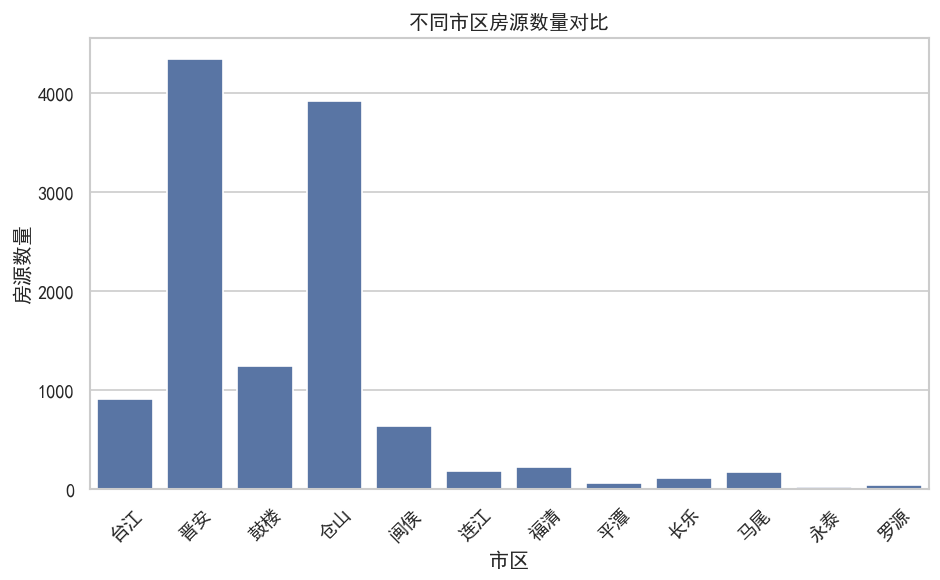

图表弹窗已弹出


In [342]:

%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("二手房清洗完成数据.csv", encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="市区")
plt.title("不同市区房源数量对比")
plt.xlabel("市区")
plt.ylabel("房源数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("图表弹窗已弹出")



图表含义
 
横轴为福州各个行政区，纵轴代表该区域二手房挂牌总量，柱子越高，说明片区在售房源越多、房产交易活跃度越高。
 
分析结果
 
1. 晋安、仓山两个区域房源数量最多，属于刚需自住主流板块，可选房源充足；
​
2. 鼓楼区作为学区核心区，挂牌房源偏少，学区房供给稀缺；
​
3. 其余片区房源数量较少，二手房流通性较差。请解释图表 1 说明了什么。

### 图表 2：各行政区平均单价对比

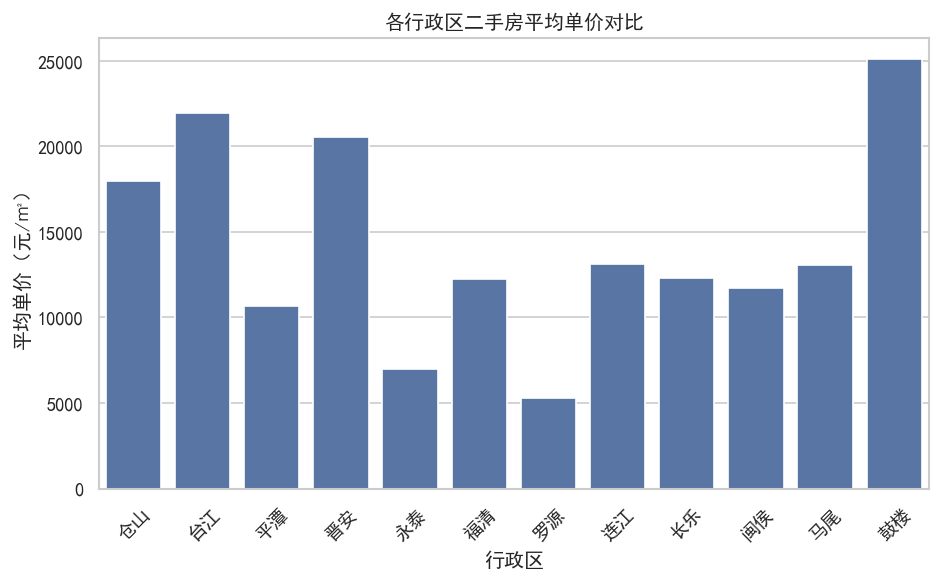

In [343]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("二手房清洗完成数据.csv", encoding="utf-8-sig")

# 图表2：各行政区平均单价对比
district_price = df.groupby("市区")["均价数值"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=district_price, x="市区", y="均价数值")
plt.title("各行政区二手房平均单价对比")
plt.xlabel("行政区")
plt.ylabel("平均单价（元/㎡）")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




图表含义
 
以柱状高度展示各区每平方米均价，直观体现不同区域的房价梯度。
 
分析结果
 
1. 鼓楼均价显著高于所有区域，学区资源带来巨大价格溢价；
​
2. 台江均价位居第二，仓山、晋安均价更低；
​
3. 地段和学区是决定房价最关键的因素，城市房价区域分层现象明显。请解释图表 2 说明了什么。

### 图表 3：总价档位房源占比饼图

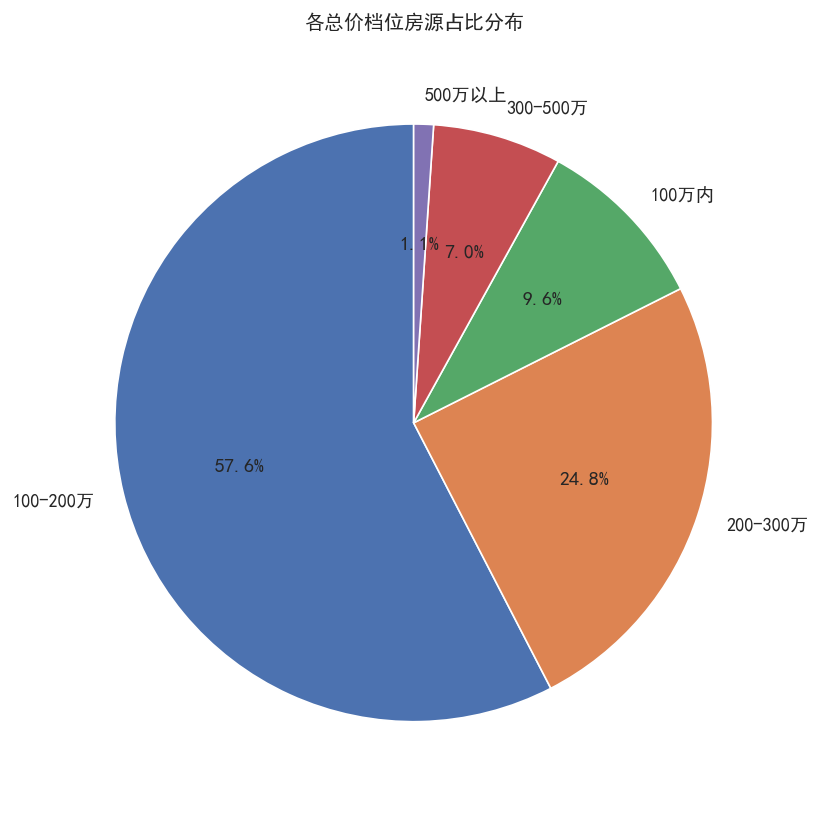

In [344]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("二手房清洗完成数据.csv", encoding="utf-8-sig")

# 图表3：总价档位房源占比饼图
price_count = df["总价档位"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(price_count.values, labels=price_count.index, autopct="%1.1f%%", startangle=90)
plt.title("各总价档位房源占比分布")
plt.axis("equal")
plt.tight_layout()
plt.show()


图表含义
 
饼图不同扇区代表不同预算区间房源的市场占比，反映整体购房需求结构。
 
分析结果
 
1. 100万-200万、200万两个档位房源占比合计超七成，是市场刚需、刚改主力；
​
2. 100万以内低价小户型、500万以上高端豪宅占比极低，可选房源稀少。请解释图表 3 说明了什么。

### 图表 4：楼层档次单价箱线图

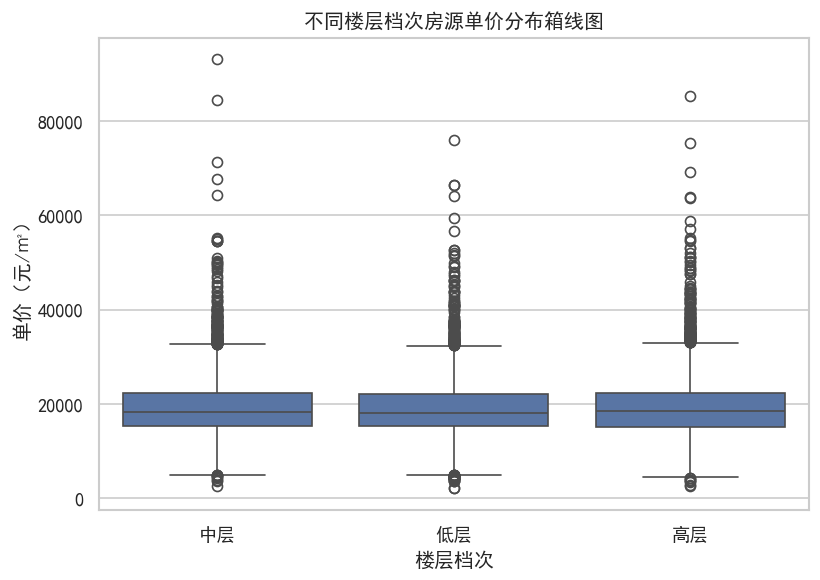

In [345]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("二手房清洗完成数据.csv", encoding="utf-8-sig")

# 图表4：楼层档次单价箱线图
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="楼层档次", y="均价数值")
plt.title("不同楼层档次房源单价分布箱线图")
plt.xlabel("楼层档次")
plt.ylabel("单价（元/㎡）")
plt.tight_layout()
plt.show()



图表含义
 
箱线图展示低层、中层、高层房源均价的中位数、四分位数和极端高价样本，对比楼层对房价的影响。
 
分析结果
 
1. 中层房源均价中位数最高，采光、视野、噪音综合条件更好，溢价更高；
​
2. 低层房源采光受限，整体均价最低；
​
3. 高层房价介于中层与低层之间，存在少量高价学区异常房源。请解释图表 4 说明了什么。

## 8. 主要结论

请用条理清晰的文字总结本次分析的主要发现。结论必须来自前面的统计结果和图表，不要凭空下结论。

可以从以下角度组织：

1. 最重要的 3 到 5 个发现是什么。
2. 哪些发现有图表或统计结果支持。
3. 数据本身有哪些局限，哪些结论需要谨慎解释。

### 8. 主要结论
#### 一、本次分析5条核心重要发现
1. **区域学区是房价第一分层因素**
   支撑依据：行政区分组聚合统计、图表2各行政区均价柱状图。
   核心内容：鼓楼核心学区行政区均价、中位数显著高于仓山、晋安、外围区县，城市二手房区域价格梯度清晰；同时图表1房源数量计数图显示鼓楼挂牌房源总量偏少，学区房供给稀缺。

2. **市场主流需求集中在100-300万中端预算区间**
   支撑依据：总价档位分组统计、图表3预算占比饼图。
   核心内容：100-200万、200-300万房源合计占市场七成以上，是刚需、刚改主力；100万以内小户型、500万以上高端豪宅供给稀缺，可选房源少。

3. **楼层存在稳定价格溢价规律，中层房源价值最高**
   支撑依据：楼层档次分组统计、图表4楼层单价箱线图。
   核心内容：同一行政区内中层房源均价中位数最高，采光、视野综合条件最优；低层房源均价整体最低；高层价格介于中层与低层之间。

4. **3室户型是市场流通主力，小户型学区房单价溢价极强**
   支撑依据：户型室数分组统计、单价TOP10排序结果。
   核心内容：3室房源样本数量最多，供需最旺盛；小户型学区房单位均价远高于大面积改善住宅，学区带来的单价增值超过户型面积带来的总价增值。

5. **刚需自住房源集中在仓山、晋安板块**
   支撑依据：图表1各区域房源数量计数图、行政区分组综合统计。
   核心内容：仓山、晋安挂牌房源数量遥遥领先其他区县，片区户型面积偏大、均价更低，适配纯自住刚需人群。

---

#### 二、各发现对应的支撑材料清单
1. 区域房价分层、片区供给热度：行政区分组聚合统计表、图表1房源数量柱状图、图表2区域均价柱状图
2. 购房预算需求结构：总价档位分组统计、图表3预算占比饼图
3. 楼层价格差异规律：楼层档次分组统计、图表4楼层单价箱线图
4. 户型流通与学区溢价：室数分组统计、高价房源筛选、单价TOP10排序结果
5. 刚需板块分布：图表1房源数量计数图、行政区综合统计

---

#### 三、数据局限与需要谨慎解释的结论
##### 1. 数据本身存在的局限
1. 样本仅为平台爬虫采集的在售挂牌房源，不包含已成交房源，仅反映挂牌市场，无法完全代表真实成交均价；
2. 数据未包含小区房龄、物业、地铁距离等配套变量，无法量化配套对房价的影响；
3. 样本无装修程度、电梯/楼梯房标签，同片区内部装修差异带来的价差无法区分；
4. 样本时间单一，缺乏跨月份、跨年份数据，无法分析房价涨跌趋势。

##### 2. 需要谨慎解读的结论
1. **“鼓楼均价最高=所有鼓楼住宅都很贵”**
   谨慎原因：均值受少量小户型天价学区房拉高，片区内大面积自住住宅价格偏低，不能一概而论；中位数更能代表普通住宅水平。
2. **“中层一定比高层更保值”**
   谨慎原因：未结合楼栋总层数、采光朝向细分，超高层楼栋中高楼层视野优势更强，本数据仅简单划分低/中/高，分类较粗糙。
3. **“100万以内房源稀缺=市场无低价需求”**
   谨慎原因：仅基于在售挂牌数据，不代表无成交，部分低价小户型成交速度快、挂牌周期短，样本捕捉不足。
4. **“3室户型溢价最高”**
   谨慎原因：未区分学区3室与郊区3室，学区小三房单价溢价远高于郊区大三房，结论不能跨片区直接套用。
